In [1]:
import pandas as pd

# =========================
# STEP 1: Load cleaned datasets
# =========================

train = pd.read_csv("train_cleaned.csv")
oil = pd.read_csv("oil_cleaned.csv")
holidays = pd.read_csv("holidays_cleaned.csv")

train["date"] = pd.to_datetime(train["date"])
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])


In [2]:
# =========================
# STEP 2: Merge train + oil
# =========================

train_oil = train.merge(
    oil,
    on="date",
    how="left"
)


In [3]:
# =========================
# STEP 3: Merge holiday
# =========================

full_data = train_oil.merge(
    holidays,
    on="date",
    how="left"
)


In [4]:
# =========================
# STEP 4.1: Fill missing holiday
# =========================

full_data["is_holiday"] = full_data["is_holiday"].fillna(0).astype(int)

# =========================
# STEP 4.2: Check missing oil_price
# =========================

print(full_data["oil_price"].isna().sum())


858924


In [5]:
# =========================
# STEP 5: Sort by time
# =========================

full_data = full_data.sort_values("date")


In [6]:
# =========================
# STEP 6: Final check
# =========================

print(full_data.head())
print(full_data.info())


              date  store_nbr              family  sales  onpromotion  year  \
0       2013-01-01          1          AUTOMOTIVE    0.0            0  2013   
2475480 2013-01-01         45           HOME CARE    0.0            0  2013   
468152  2013-01-01          9            HARDWARE    0.0            0  2013   
2473796 2013-01-01         45     HOME APPLIANCES    0.0            0  2013   
469836  2013-01-01          9  HOME AND KITCHEN I    0.0            0  2013   

         month  dayofweek  is_weekend  oil_price  oil_price_lag_1  \
0            1          1           0        NaN              NaN   
2475480      1          1           0        NaN              NaN   
468152       1          1           0        NaN              NaN   
2473796      1          1           0        NaN              NaN   
469836       1          1           0        NaN              NaN   

         oil_price_lag_7  is_holiday  
0                    NaN           1  
2475480              NaN        

In [7]:
# =========================
# STEP 7: Save merged dataset
# =========================

full_data.to_csv("full_data_merged.csv", index=False)


In [8]:
# Basic overview
full_data.info = {
    "num_rows": full_data.shape[0],
    "num_columns": full_data.shape[1],
    "columns": list(full_data.columns),
    "date_min": full_data["date"].min() if "date" in full_data.columns else None,
    "date_max": full_data["date"].max() if "date" in full_data.columns else None
}
full_data.info

{'num_rows': 3000888,
 'num_columns': 13,
 'columns': ['date',
  'store_nbr',
  'family',
  'sales',
  'onpromotion',
  'year',
  'month',
  'dayofweek',
  'is_weekend',
  'oil_price',
  'oil_price_lag_1',
  'oil_price_lag_7',
  'is_holiday'],
 'date_min': Timestamp('2013-01-01 00:00:00'),
 'date_max': Timestamp('2017-08-15 00:00:00')}

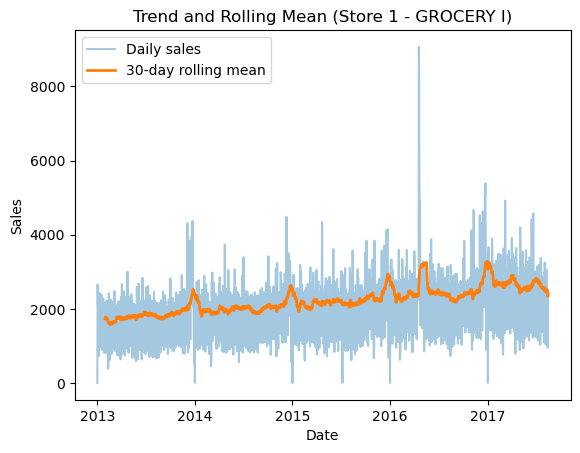

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv("full_data_merged.csv", parse_dates=["date"])

# =========================
# 1. Trend + Rolling Mean
# =========================
sample = (
    df[(df["store_nbr"] == 1) & (df["family"] == "GROCERY I")]
    .sort_values("date")
    .copy()
)

sample["rolling_30"] = sample["sales"].rolling(window=30).mean()

plt.figure()
plt.plot(sample["date"], sample["sales"], alpha=0.4, label="Daily sales")
plt.plot(sample["date"], sample["rolling_30"], linewidth=2, label="30-day rolling mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Trend and Rolling Mean (Store 1 - GROCERY I)")
plt.legend()
plt.show()



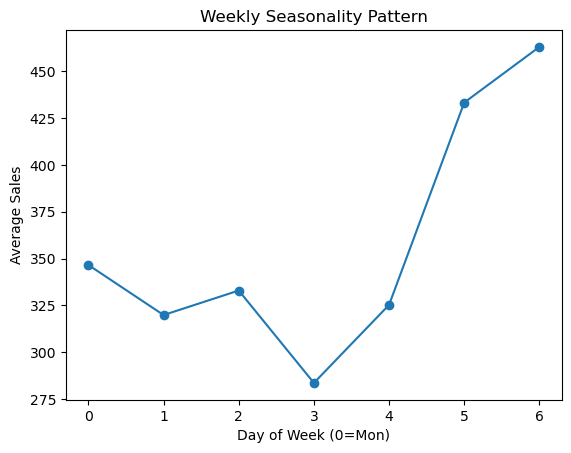

In [10]:
# =========================
# 2. Weekly Seasonality (day of week)
# =========================
df["day_of_week"] = df["date"].dt.dayofweek

weekly = df.groupby("day_of_week")["sales"].mean()

plt.figure()
plt.plot(weekly.index, weekly.values, marker="o")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Sales")
plt.title("Weekly Seasonality Pattern")
plt.show()

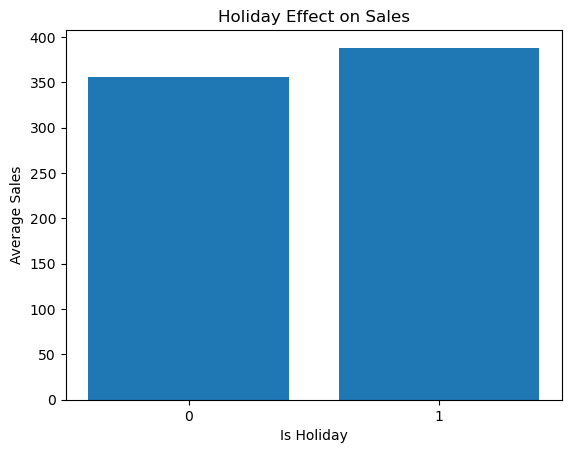

In [11]:
# =========================
# 3. Holiday vs Non-Holiday
# =========================
holiday_sales = df.groupby("is_holiday")["sales"].mean()

plt.figure()
plt.bar(holiday_sales.index.astype(str), holiday_sales.values)
plt.xlabel("Is Holiday")
plt.ylabel("Average Sales")
plt.title("Holiday Effect on Sales")
plt.show()

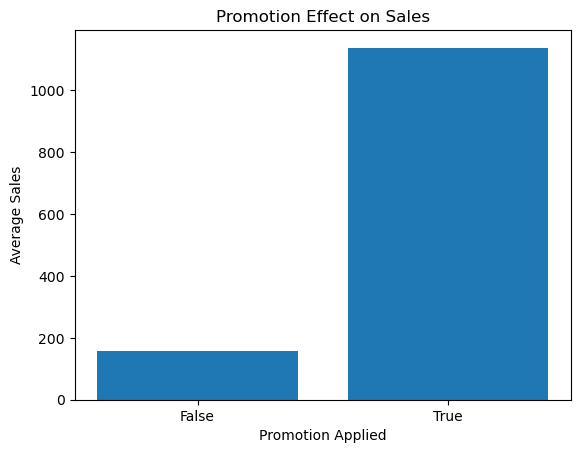

In [12]:
# =========================
# 4. Promotion Effect
# =========================
promo = df.copy()
promo["has_promo"] = promo["onpromotion"] > 0

promo_sales = promo.groupby("has_promo")["sales"].mean()

plt.figure()
plt.bar(promo_sales.index.astype(str), promo_sales.values)
plt.xlabel("Promotion Applied")
plt.ylabel("Average Sales")
plt.title("Promotion Effect on Sales")
plt.show()

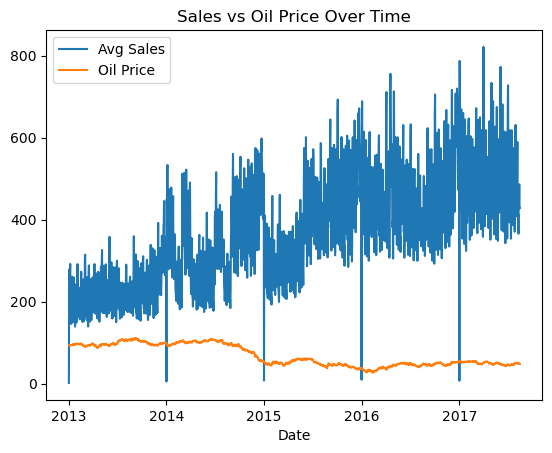

In [13]:
# =========================
# 5. Oil Price vs Sales (Aggregated)
# =========================
oil_daily = df.groupby("date")[["sales", "oil_price"]].mean()

plt.figure()
plt.plot(oil_daily.index, oil_daily["sales"], label="Avg Sales")
plt.plot(oil_daily.index, oil_daily["oil_price"], label="Oil Price")
plt.xlabel("Date")
plt.title("Sales vs Oil Price Over Time")
plt.legend()
plt.show()